In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import math
import cv2
import numpy as np
from PIL import Image
import timm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# === CONFIG ===
epochs = 100
batch_size = 32
num_classes = 4
learning_rate = 3e-5  # Recommended for DeiT fine-tuning
weight_decay = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === LEAF SEGMENTATION ===
def segment_leaf(img):
    img_np = np.array(img)
    hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
    lower = np.array([25, 40, 40])
    upper = np.array([95, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    if np.count_nonzero(mask) == 0:
        return Image.fromarray(img_np)
    result = cv2.bitwise_and(img_np, img_np, mask=mask)
    ys, xs = np.where(mask > 0)
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    cropped = result[y_min:y_max, x_min:x_max]
    resized = cv2.resize(cropped, (img_np.shape[1], img_np.shape[0]))
    return Image.fromarray(resized)

# === TRANSFORMS ===
train_transforms = transforms.Compose([
    transforms.Lambda(lambda img: segment_leaf(img)),
    transforms.RandomRotation(degrees=20),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Lambda(lambda img: segment_leaf(img)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === DATASETS ===
train_dataset = datasets.ImageFolder('/kaggle/input/plant-village-dataset/PlantVillage/train', transform=train_transforms)
val_dataset = datasets.ImageFolder('/kaggle/input/plant-village-dataset/PlantVillage/val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# === MODEL: DEIT ===
model = timm.create_model('deit_base_patch16_224', pretrained=True, num_classes=num_classes)
model = model.to(device)

# === LOSS, OPTIMIZER, LR SCHEDULER ===
train_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
val_criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

def get_cosine_schedule_with_warmup(optimizer, num_warmup_epochs, num_training_epochs):
    def lr_lambda(current_epoch):
        if current_epoch < num_warmup_epochs:
            return float(current_epoch) / float(max(1, num_warmup_epochs))
        return 0.5 * (1. + math.cos(math.pi * (current_epoch - num_warmup_epochs) / (num_training_epochs - num_warmup_epochs)))
    return LambdaLR(optimizer, lr_lambda)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_epochs=5, num_training_epochs=epochs)

# === TRAINING FUNCTIONS ===
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects.double() / len(loader.dataset)
    return epoch_loss, epoch_acc.item()

def validate(model, loader, criterion,num_classes):
    model.eval()
    running_loss, running_corrects = 0.0, 0
    all_labels, all_probs = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            

            probs = torch.softmax(outputs, dim=1)  # probabilities
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects.double() / len(loader.dataset)
    
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    
    return epoch_loss, epoch_acc.item(), all_labels, all_probs

# === TRAINING LOOP ===
print("Starting Training......\n")
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


for epoch in range(epochs):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, train_criterion)
    if epoch == epochs - 1:  # last epoch -> collect ROC data
        val_loss, val_acc, y_true, y_prob = validate(model, val_loader, val_criterion, num_classes)
    else:
        val_loss, val_acc, _, _ = validate(model, val_loader, val_criterion, num_classes)
    
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"\u23f1 Time taken: {time.time() - start:.2f} seconds\n")

print("Training Ended")


Starting Training......

Epoch 1/100
Train Loss: 1.5017, Train Acc: 0.2299
Val Loss: 1.4898, Val Acc: 0.2073
⏱ Time taken: 81.50 seconds

Epoch 2/100
Train Loss: 0.7677, Train Acc: 0.8091
Val Loss: 0.3751, Val Acc: 0.9041
⏱ Time taken: 81.86 seconds

Epoch 3/100
Train Loss: 0.4732, Train Acc: 0.9451
Val Loss: 0.2818, Val Acc: 0.9158
⏱ Time taken: 81.66 seconds

Epoch 4/100
Train Loss: 0.4310, Train Acc: 0.9640
Val Loss: 0.2203, Val Acc: 0.9417
⏱ Time taken: 81.67 seconds

Epoch 5/100
Train Loss: 0.4111, Train Acc: 0.9753
Val Loss: 0.1703, Val Acc: 0.9663
⏱ Time taken: 82.10 seconds

Epoch 6/100
Train Loss: 0.3937, Train Acc: 0.9799
Val Loss: 0.1627, Val Acc: 0.9689
⏱ Time taken: 81.55 seconds

Epoch 7/100
Train Loss: 0.3817, Train Acc: 0.9883
Val Loss: 0.1964, Val Acc: 0.9560
⏱ Time taken: 82.32 seconds

Epoch 8/100
Train Loss: 0.3817, Train Acc: 0.9873
Val Loss: 0.1740, Val Acc: 0.9650
⏱ Time taken: 81.81 seconds

Epoch 9/100
Train Loss: 0.3678, Train Acc: 0.9942
Val Loss: 0.1473, Val

In [5]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_preds.double() / total_samples

    return epoch_loss, epoch_acc.item()

# After training
final_train_loss, final_train_acc = evaluate(model, train_loader, train_criterion, device)
print(f"Final Training Loss: {final_train_loss:.4f}, Final Training Accuracy: {final_train_acc * 100:.2f}%")

final_val_loss, final_val_acc = evaluate(model, val_loader, val_criterion,device)
print(f"\nFinal Validation Loss: {final_val_loss:.4f}, Final Validation Accuracy: {final_val_acc * 100:.2f}%")

Final Training Loss: 0.3489, Final Training Accuracy: 100.00%

Final Validation Loss: 0.1340, Final Validation Accuracy: 98.19%


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return epoch_loss, accuracy, precision, recall, f1


train_loss, train_acc, train_prec, train_rec, train_f1 = evaluate(model, train_loader, train_criterion, device)
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Acc: {train_acc*100:.2f}%, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}, F1: {train_f1:.4f}")

val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader, val_criterion, device)
print(f"\nVal Loss: {val_loss:.4f}")
print(f"Val Acc: {val_acc*100:.2f}%, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}, F1: {val_f1:.4f}")


Train Loss: 0.3489
Train Acc: 100.00%, Precision: 1.0000, Recall: 1.0000, F1: 1.0000

Val Loss: 0.1340
Val Acc: 98.19%, Precision: 0.9757, Recall: 0.9755, F1: 0.9756


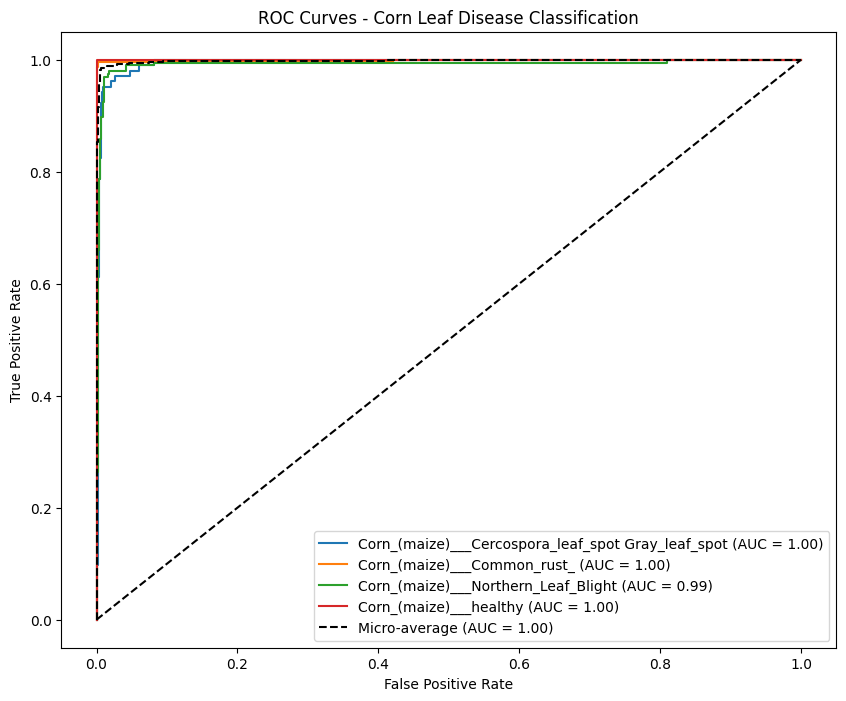

In [7]:
# === ROC CURVES ===
classes = list(train_dataset.class_to_idx.keys())
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

# Micro-average
fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, linestyle='--', color='black', label=f"Micro-average (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Corn Leaf Disease Classification")
plt.legend(loc="lower right")
plt.show()

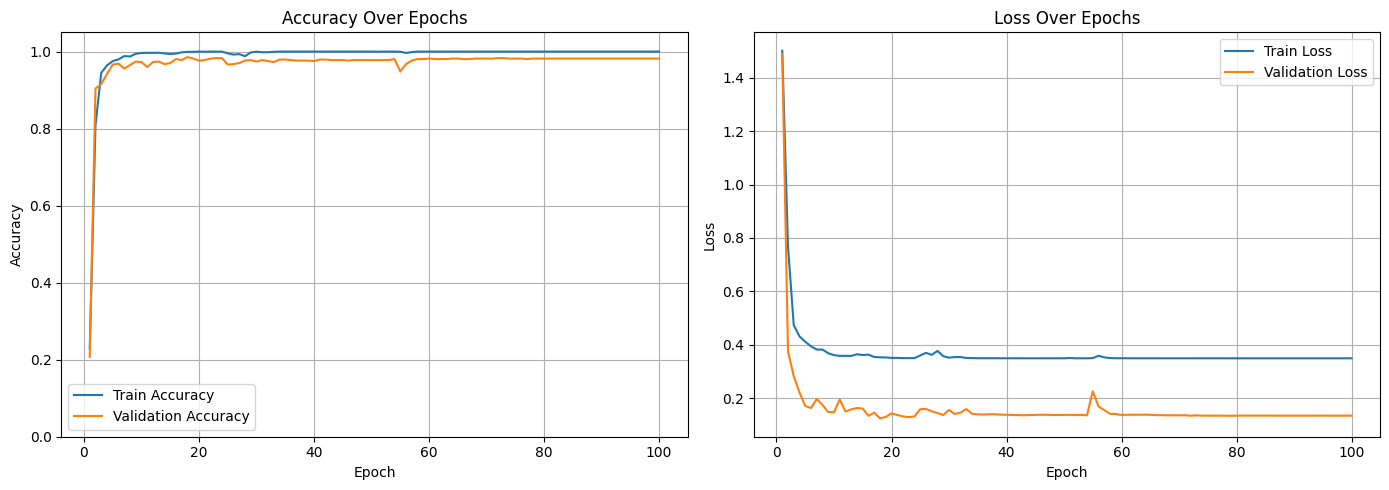

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

# === ACCURACY CURVE ===
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

# === LOSS CURVE ===
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

== Final Train Set Evaluation ==
Loss: 0.3489 | Acc: 100.00% | Prec: 1.0000 | Recall: 1.0000 | F1: 1.0000


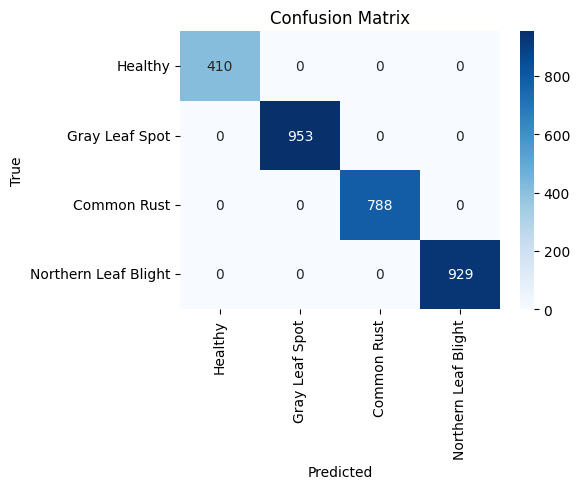

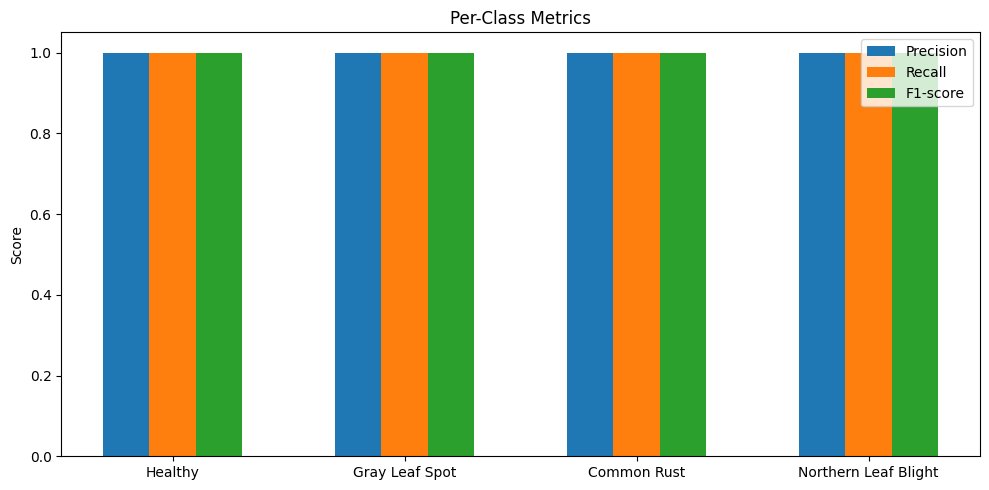


== Final Validation Set Evaluation ==
Loss: 0.1340 | Acc: 98.19% | Prec: 0.9757 | Recall: 0.9755 | F1: 0.9756


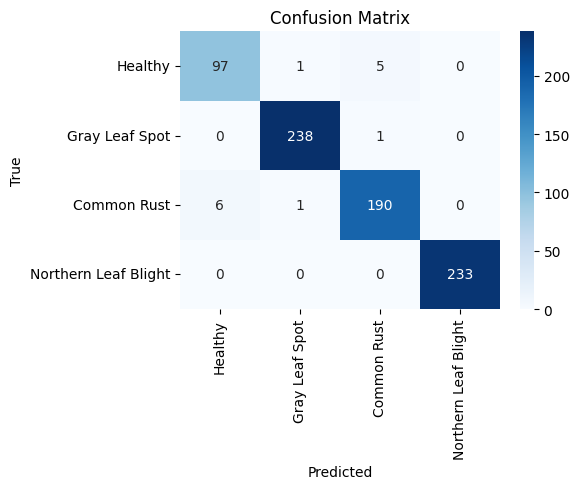

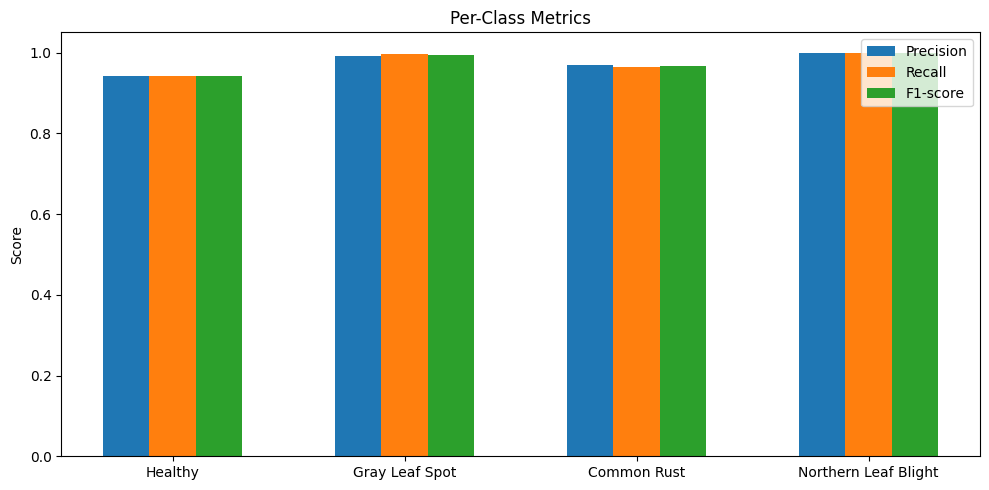

(0.1339684342241658,
 0.9818652849740933,
 0.9757004986460603,
 0.9755076193683165,
 0.975601411097927)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

def evaluate_and_plot(model, dataloader, criterion, device, class_names):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === METRICS ===
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"Loss: {epoch_loss:.4f} | Acc: {acc*100:.2f}% | Prec: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

    # === CONFUSION MATRIX ===
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    # === PER-CLASS METRICS ===
    class_report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
    precision_vals = [class_report[cls]['precision'] for cls in class_names]
    recall_vals = [class_report[cls]['recall'] for cls in class_names]
    f1_vals = [class_report[cls]['f1-score'] for cls in class_names]

    x = range(len(class_names))
    width = 0.2

    plt.figure(figsize=(10, 5))
    plt.bar([i - width for i in x], precision_vals, width=width, label='Precision')
    plt.bar(x, recall_vals, width=width, label='Recall')
    plt.bar([i + width for i in x], f1_vals, width=width, label='F1-score')
    plt.xticks(x, class_names)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Per-Class Metrics")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return epoch_loss, acc, prec, rec, f1

# Example usage (assuming 4 classes)
class_names = ['Healthy', 'Gray Leaf Spot', 'Common Rust', 'Northern Leaf Blight']

print("== Final Train Set Evaluation ==")
evaluate_and_plot(model, train_loader, train_criterion, device, class_names)

print("\n== Final Validation Set Evaluation ==")
evaluate_and_plot(model, val_loader, val_criterion, device, class_names)